# This notebook reproduces following figures: Fig. 8, Fig. 9, Fig. S5.

Following network files were used to simulate the networks:
- nw_iall_disinhibition_ingram_v2.py
- nw_iall_disinhibition_noningram_v2.py

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from matplotlib.patches import Ellipse

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## Fig 8: Embedding an engram alone is enough to recruit a functional ingram.

/home/mkania/miniforge3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:120: RuntimeWarning: invalid value encountered in greater
/home/mkania/miniforge3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:121: RuntimeWarning: invalid value encountered in greater


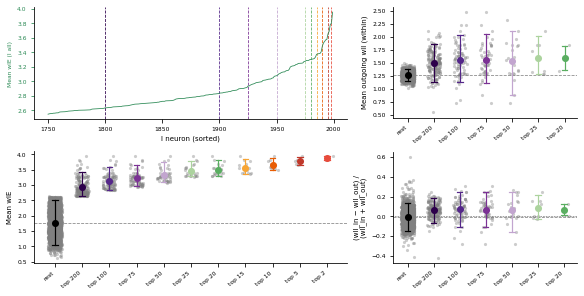

In [2]:
# load data
GROUPS_FILE  = "data/fig8_9/42_inhibitory_groups_topN.npz"
WEIGHTS_FILE = "data/fig8_9/full_after_engram_weights_and_connectivity_iall_600sec.npz"

d_iall = np.load(WEIGHTS_FILE)
grp    = np.load(GROUPS_FILE, allow_pickle=True)

group_sizes = [200, 100, 75, 50, 25, 20, 15, 10, 5, 2, 1]
palette     = ["#000000",
               "#2D004B", "#542789", "#7B3294", "#C2A5CF",
               "#ACD39E", "#5AAE61", "#F7A535", "#E85D04",
               "#C0392B", "#E74C3C"]
x_pos   = np.arange(len(group_sizes) + 1)
xlabels = ["rest"] + [f"top {n}" for n in group_sizes]

def has_data(subsets):
    return any(np.any(np.isfinite(s)) for s in subsets)

def draw_boxplot(ax, subsets, ylabel):
    any_drawn = False

    indexed = [(i, s, palette[i]) for i, s in enumerate(subsets)
               if i < len(palette) and np.any(np.isfinite(s))]

    for i, subset, col in indexed:
        s = subset[np.isfinite(subset)]
        if len(s) == 0:
            continue
        any_drawn = True
        x = x_pos[i]

        jitter = np.random.uniform(-0.25, 0.25, size=len(s))
        ax.scatter(x + jitter, s, color="grey", rasterized=True, s=10, alpha=0.4,
                   linewidths=0, zorder=1)

        m    = np.mean(s)
        w_lo = np.percentile(s, 5)
        w_hi = np.percentile(s, 95)

        if w_hi > w_lo:
            ax.plot([x, x], [w_lo, w_hi], color=col, lw=1.2, zorder=3)
            ax.plot([x-0.10, x+0.10], [w_lo, w_lo], color=col, lw=1.2, zorder=3)
            ax.plot([x-0.10, x+0.10], [w_hi, w_hi], color=col, lw=1.2, zorder=3)
        ax.scatter(x, m, color=col, s=50, zorder=4, linewidths=0)

    shown_ticks  = [x_pos[i] for i, _, _ in indexed]
    shown_labels = [xlabels[i] for i, _, _ in indexed]
    ax.set_xticks(shown_ticks)
    ax.set_xticklabels(shown_labels, fontsize=6, rotation=40, ha="right")
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return any_drawn

def compute_sorted_wIE(d):
    total_exc = int(d["total_exc"])
    if "total_inh" in d.files:
        total_inh = int(d["total_inh"])
    else:
        max_id = int(np.max([np.max(d["pre_IE"]), np.max(d["post_IE"]),
                             np.max(d["pre_II"]), np.max(d["post_II"])]))
        total_inh = (max_id + 1) - total_exc

    pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]
    E_engram = np.arange(0, 784)

    mask_ie = np.isin(post_IE, E_engram) & np.isfinite(w_IE)
    n_ie = np.zeros(total_inh, dtype=int)
    s_ie = np.zeros(total_inh, dtype=float)
    for i_abs, w in zip(pre_IE[mask_ie], w_IE[mask_ie]):
        idx = i_abs - total_exc
        n_ie[idx] += 1
        s_ie[idx] += w

    avg_wIE = np.full(total_inh, np.nan)
    has_ie  = n_ie > 0
    avg_wIE[has_ie] = s_ie[has_ie] / n_ie[has_ie]

    has_ie_mask = np.isfinite(avg_wIE)
    sort_order  = np.argsort(avg_wIE[has_ie_mask])
    sorted_wIE  = avg_wIE[has_ie_mask][sort_order]
    neuron_ids  = np.where(has_ie_mask)[0] + total_exc
    sorted_ids  = neuron_ids[sort_order]

    return sorted_wIE, sorted_ids, total_exc, total_inh

def compute_wII_within_external(d, group_abs_ids):
    pre_II, post_II, w_II = d["pre_II"], d["post_II"], d["w_II"]
    idx_map = {abs_id: i for i, abs_id in enumerate(group_abs_ids)}

    mask_in  = (np.isin(pre_II, group_abs_ids) &
                np.isin(post_II, group_abs_ids) &
                np.isfinite(w_II))
    mask_out = (np.isin(pre_II, group_abs_ids) &
                ~np.isin(post_II, group_abs_ids) &
                np.isfinite(w_II))

    n_in  = np.zeros(len(group_abs_ids), dtype=int)
    s_in  = np.zeros(len(group_abs_ids), dtype=float)
    n_out = np.zeros(len(group_abs_ids), dtype=int)
    s_out = np.zeros(len(group_abs_ids), dtype=float)

    for pre, w in zip(pre_II[mask_in],  w_II[mask_in]):
        n_in[idx_map[pre]]  += 1
        s_in[idx_map[pre]]  += w
    for pre, w in zip(pre_II[mask_out], w_II[mask_out]):
        n_out[idx_map[pre]] += 1
        s_out[idx_map[pre]] += w

    avg_in  = np.full(len(group_abs_ids), np.nan)
    avg_out = np.full(len(group_abs_ids), np.nan)
    avg_in[n_in   > 0] = s_in[n_in   > 0]  / n_in[n_in   > 0]
    avg_out[n_out > 0] = s_out[n_out > 0]  / n_out[n_out > 0]

    contrast = np.full(len(group_abs_ids), np.nan)
    valid = (n_in > 0) & (n_out > 0)
    denom = avg_in + avg_out
    contrast[valid & (denom > 0)] = (
        (avg_in[valid & (denom > 0)] - avg_out[valid & (denom > 0)]) /
         denom[valid & (denom > 0)]
    )
    return avg_in, avg_out, contrast

sorted_wIE, sorted_ids, total_exc, total_inh = compute_sorted_wIE(d_iall)
N = len(sorted_wIE)

groups_ids = [grp["rest"]] + [grp[f"top_{n}"] for n in group_sizes]

# IE subsets
id_to_rank = {nid: i for i, nid in enumerate(sorted_ids)}
subsets_ie = []
for ids in groups_ids:
    ranks = np.array([id_to_rank[nid] for nid in ids if nid in id_to_rank])
    subsets_ie.append(sorted_wIE[ranks] if len(ranks) > 0 else np.array([np.nan]))

# wII subsets
subsets_ii_in    = []
subsets_ii_out   = []
subsets_contrast = []
for ids in groups_ids:
    w_in, w_out, contrast = compute_wII_within_external(d_iall, ids)
    subsets_ii_in.append(w_in)
    subsets_ii_out.append(w_out)
    subsets_contrast.append(contrast)

show_wii      = has_data(subsets_ii_in)
show_contrast = has_data(subsets_contrast)
n_right       = int(show_wii) + int(show_contrast)

ratio_l = 1.5
ratio_r = 1

if n_right == 2:
    fig = plt.figure(figsize=(8, 4), constrained_layout=True)
    gs  = GridSpec(1, 2, figure=fig, width_ratios=[ratio_l, ratio_r])
    gs_left  = gs[0].subgridspec(2, 1, hspace=0.55)
    gs_right = gs[1].subgridspec(2, 1, hspace=0.55)
    ax_top   = fig.add_subplot(gs_left[0])
    ax_bot   = fig.add_subplot(gs_left[1])
    ax_wii   = fig.add_subplot(gs_right[0]) if show_wii      else None
    ax_ratio = fig.add_subplot(gs_right[1]) if show_contrast else None
elif n_right == 1:
    fig = plt.figure(figsize=(8, 4), constrained_layout=True)
    gs  = GridSpec(1, 3, figure=fig, width_ratios=[ratio_l, ratio_l, ratio_r])
    ax_top   = fig.add_subplot(gs[0])
    ax_bot   = fig.add_subplot(gs[1])
    ax_wii   = fig.add_subplot(gs[2]) if show_wii      else None
    ax_ratio = fig.add_subplot(gs[2]) if show_contrast else None
else:
    fig = plt.figure(figsize=(8, 4), constrained_layout=True)
    gs  = GridSpec(1, 2, figure=fig)
    ax_top   = fig.add_subplot(gs[0])
    ax_bot   = fig.add_subplot(gs[1])
    ax_wii   = None
    ax_ratio = None

lo, hi = N - max(group_sizes) - 50, N
ax_top.plot(np.arange(lo, hi), sorted_wIE[lo:hi], color="seagreen", lw=0.8)
ax_top.set_ylabel("Mean wIE (I all)", color="seagreen", fontsize=6)
ax_top.tick_params(axis="y", colors="seagreen", labelsize=6)
for n, color in zip(group_sizes, palette[1:]):
    ax_top.axvline(N - n, color=color, lw=0.8, ls="--", zorder=0, label=f"top {n}")
ax_top.set_xlabel("I neuron (sorted)", fontsize=7)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.tick_params(labelsize=6)

draw_boxplot(ax_bot, subsets_ie, "Mean wIE")

if ax_wii is not None:
    drawn = draw_boxplot(ax_wii, subsets_ii_in, "Mean outgoing wII (within)")
    if not drawn:
        ax_wii.set_visible(False)

if ax_ratio is not None:
    drawn = draw_boxplot(ax_ratio, subsets_contrast,
                         "(wII_in − wII_out) /\n(wII_in + wII_out)")
    if not drawn:
        ax_ratio.set_visible(False)

# dashed lines 
grey_ie = subsets_ie[0][np.isfinite(subsets_ie[0])]
if len(grey_ie) > 0:
    ax_bot.axhline(np.nanmean(grey_ie), color="#888888", lw=0.8, ls="--", zorder=0)

if ax_wii is not None and ax_wii.get_visible():
    grey_wii = subsets_ii_in[0][np.isfinite(subsets_ii_in[0])]
    if len(grey_wii) > 0:
        ax_wii.axhline(np.nanmean(grey_wii), color="#888888", lw=0.8, ls="--", zorder=0)

if ax_ratio is not None and ax_ratio.get_visible():
    grey_contrast = subsets_contrast[0][np.isfinite(subsets_contrast[0])]
    if len(grey_contrast) > 0:
        ax_ratio.axhline(np.nanmean(grey_contrast), color="#888888",
                         lw=0.8, ls="--", zorder=0)
    ax_ratio.axhline(0, color="black", lw=0.6, ls=":", zorder=0)

plt.show()

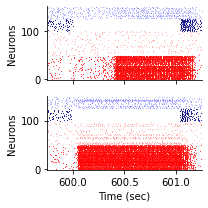

In [3]:
base_dir_25 = "data/fig8_9/top_25_ingram_iall_42_3.0_10.0_42_615sec_filtered"
base_dir_100   = "data/fig8_9/top_100_ingram_iall_42_3.0_10.0_42_615sec_filtered"

tmin, tmax = 599.75, 601.25

n_E_low   = 50
n_E_high  = 50
n_I_inhib = 25
n_I_rest  = 25

seed = 0
rng = np.random.default_rng(seed)

E_MIN, E_MAX = 0, 8000
I_MIN, I_MAX = 8000, 10000
N_I = 2000

def build_raster_data(base_dir):
    spike_path   = os.path.join(base_dir, "spikes.txt")
    inh_idx_path = os.path.join(base_dir, "inhibited_indices.txt")

    data = np.loadtxt(spike_path)
    neuron = data[:, 0].astype(int)
    time   = data[:, 1]

    inh_idx_raw = np.loadtxt(inh_idx_path)
    if inh_idx_raw.ndim == 0:
        inh_idx_raw = np.array([inh_idx_raw])
    elif inh_idx_raw.ndim > 1:
        inh_idx_raw = inh_idx_raw[:, 0]
    inh_idx_raw = inh_idx_raw.astype(int)

    if inh_idx_raw.size and inh_idx_raw.max() < N_I:
        inhibited_ids_all = I_MIN + inh_idx_raw
    else:
        inhibited_ids_all = inh_idx_raw

    inhibited_ids_all = inhibited_ids_all[
        (inhibited_ids_all >= I_MIN) & (inhibited_ids_all < I_MAX)
    ]
    inhibited_ids_all = np.unique(inhibited_ids_all)

    all_inh_ids = np.arange(I_MIN, I_MAX)
    rest_inh_ids_all = np.setdiff1d(all_inh_ids, inhibited_ids_all)

    I_inhib_ids = inhibited_ids_all[:min(n_I_inhib, inhibited_ids_all.size)]
    I_rest_ids  = rng.choice(rest_inh_ids_all, size=min(n_I_rest, rest_inh_ids_all.size), replace=False)

    # engram neurons
    E_low_ids  = rng.choice(np.arange(0, 784),  size=n_E_low,  replace=False)
    E_high_ids = rng.choice(np.arange(784, 8000), size=n_E_high, replace=False)

    sel_ids = np.concatenate([E_low_ids, E_high_ids, I_inhib_ids, I_rest_ids])
    id_to_y = {nid: i for i, nid in enumerate(sel_ids)}

    mask_w = (time >= tmin) & (time <= tmax)
    neuron_w = neuron[mask_w]
    time_w   = time[mask_w]

    mask_sel = np.isin(neuron_w, sel_ids)
    neuron_sel = neuron_w[mask_sel]
    time_sel   = time_w[mask_sel]

    y_disp = np.array([id_to_y[n] for n in neuron_sel])

    m_E_low  = np.isin(neuron_sel, E_low_ids)
    m_E_high = np.isin(neuron_sel, E_high_ids)
    m_I_inh  = np.isin(neuron_sel, I_inhib_ids)
    m_I_res  = np.isin(neuron_sel, I_rest_ids)

    return time_sel, y_disp, m_E_low, m_E_high, m_I_inh, m_I_res, sel_ids.size

data_25 = build_raster_data(base_dir_25)
data_100 = build_raster_data(base_dir_100)

# plotting
fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 3),
    sharex=True
)

for ax, data, title in zip(
    axes,
    [data_25, data_100],
    ["25", "100"]
):
    time_sel, y_disp, m_E_low, m_E_high, m_I_inh, m_I_res, n_total = data

    ax.scatter(time_sel[m_E_low],  y_disp[m_E_low],  s=5, c="red",  alpha=0.8, linewidths=0, marker=".", rasterized=True)
    ax.scatter(time_sel[m_E_high], y_disp[m_E_high], s=5, c="red",  alpha=0.3, linewidths=0, marker=".", rasterized=True)
    ax.scatter(time_sel[m_I_inh],  y_disp[m_I_inh],  s=5, c="navy", alpha=0.9, linewidths=0, marker=".", rasterized=True)
    ax.scatter(time_sel[m_I_res],  y_disp[m_I_res],  s=5, c="blue", alpha=0.3, linewidths=0, marker=".", rasterized=True)

    ax.set_ylim(-1, n_total)
    ax.set_xlim(tmin, tmax)
    ax.set_ylabel("Neurons")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].set_xlabel("Time (sec)")

plt.tight_layout()
plt.show()

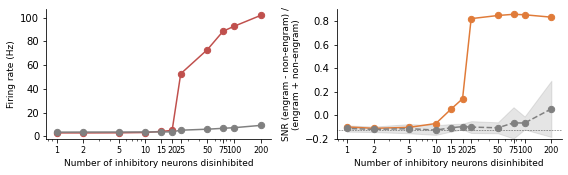

In [4]:
IN_CSV      = "data/fig8_9/ingram_snr_data_iall.csv"
group_sizes = [200, 100, 75, 50, 25, 20, 15, 10, 5, 2, 1]

df  = pd.read_csv(IN_CSV)
top = df[df["kind"] == "top"].set_index("n").reindex(group_sizes)
rest = df[df["kind"] == "rest"]

x = np.array(group_sizes, dtype=float)

top_r_eng = top["rate_engram"].values
top_r_non = top["rate_nonengram"].values
top_snr_s = top["snr_stim"].values
top_snr_b = top["snr_base"].values

rest_snr_s_mean = rest.groupby("n")["snr_stim"].mean().reindex(group_sizes).values
rest_snr_s_std  = rest.groupby("n")["snr_stim"].std().reindex(group_sizes).values

def plot_line_with_band(ax, x, mean, std, color, label, linestyle="--"):
    valid = ~np.isnan(mean)
    ax.plot(x[valid], mean[valid], color=color, lw=1.5,
            linestyle=linestyle, zorder=2, label=label)
    ax.scatter(x[valid], mean[valid], color=color, s=40, zorder=3)
    ax.fill_between(x[valid],
                    mean[valid] - std[valid],
                    mean[valid] + std[valid],
                    color=color, alpha=0.2, zorder=1)

# Plotting
fig, (ax_rate, ax_snr) = plt.subplots(1, 2, figsize=(8, 2.5))

# Activity
valid = ~np.isnan(top_r_eng)
ax_rate.plot(x[valid], top_r_eng[valid], color="#C0504D", lw=1.5,
             zorder=2, label="engram (top)")
ax_rate.scatter(x[valid], top_r_eng[valid], color="#C0504D", s=40, zorder=3)

valid = ~np.isnan(top_r_non)
ax_rate.plot(x[valid], top_r_non[valid], color="grey", lw=1.5,
             zorder=2, label="non-engram (top)")
ax_rate.scatter(x[valid], top_r_non[valid], color="grey", s=40, zorder=3)

ax_rate.set_xscale("log")
ax_rate.set_xticks(x)
ax_rate.set_xticklabels(group_sizes, fontsize=8)
ax_rate.set_ylabel("Firing rate (Hz)", fontsize=9)
ax_rate.set_xlabel("Number of inhibitory neurons disinhibited", fontsize=9)
ax_rate.spines["top"].set_visible(False)
ax_rate.spines["right"].set_visible(False)

# SNR
valid = ~np.isnan(top_snr_s)
ax_snr.plot(x[valid], top_snr_s[valid], color="#E07B39", lw=1.5,
            zorder=2, label="600-601s (top)")
ax_snr.scatter(x[valid], top_snr_s[valid], color="#E07B39", s=40, zorder=3)

plot_line_with_band(ax_snr, x, rest_snr_s_mean, rest_snr_s_std,
                    "grey", "600-601s (rest)")

ax_snr.set_xscale("log")
ax_snr.set_xticks(x)
ax_snr.set_xticklabels(group_sizes, fontsize=8)
ax_snr.set_ylabel("SNR (engram - non-engram) /\n(engram + non-engram)", fontsize=9)
ax_snr.set_xlabel("Number of inhibitory neurons disinhibited", fontsize=9)
ax_snr.axhline(-0.126, color="black", lw=0.6, ls=":", zorder=1)
ax_snr.spines["top"].set_visible(False)
ax_snr.spines["right"].set_visible(False)
ax_snr.set_ylim(-0.2, 0.9)

plt.tight_layout()
plt.show()

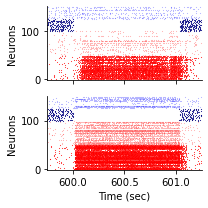

In [5]:
base_dir_25 = "data/fig8_9/top_25_ingram_ie_42_3.0_10.0_42_615sec_filtered"
base_dir_100   = "data/fig8_9/top_100_ingram_ie_42_3.0_10.0_42_615sec_filtered"

tmin, tmax = 599.75, 601.25

n_E_low   = 50
n_E_high  = 50
n_I_inhib = 25
n_I_rest  = 25

seed = 0
rng = np.random.default_rng(seed)

E_MIN, E_MAX = 0, 8000
I_MIN, I_MAX = 8000, 10000
N_I = 2000

def build_raster_data(base_dir):
    spike_path   = os.path.join(base_dir, "spikes.txt")
    inh_idx_path = os.path.join(base_dir, "inhibited_indices.txt")

    data = np.loadtxt(spike_path)
    neuron = data[:, 0].astype(int)
    time   = data[:, 1]

    inh_idx_raw = np.loadtxt(inh_idx_path)
    if inh_idx_raw.ndim == 0:
        inh_idx_raw = np.array([inh_idx_raw])
    elif inh_idx_raw.ndim > 1:
        inh_idx_raw = inh_idx_raw[:, 0]
    inh_idx_raw = inh_idx_raw.astype(int)

    if inh_idx_raw.size and inh_idx_raw.max() < N_I:
        inhibited_ids_all = I_MIN + inh_idx_raw
    else:
        inhibited_ids_all = inh_idx_raw

    inhibited_ids_all = inhibited_ids_all[
        (inhibited_ids_all >= I_MIN) & (inhibited_ids_all < I_MAX)
    ]
    inhibited_ids_all = np.unique(inhibited_ids_all)

    all_inh_ids = np.arange(I_MIN, I_MAX)
    rest_inh_ids_all = np.setdiff1d(all_inh_ids, inhibited_ids_all)

    I_inhib_ids = inhibited_ids_all[:min(n_I_inhib, inhibited_ids_all.size)]
    I_rest_ids  = rng.choice(rest_inh_ids_all, size=min(n_I_rest, rest_inh_ids_all.size), replace=False)

    # engram neurons
    E_low_ids  = rng.choice(np.arange(0, 784),  size=n_E_low,  replace=False)
    E_high_ids = rng.choice(np.arange(784, 8000), size=n_E_high, replace=False)

    sel_ids = np.concatenate([E_low_ids, E_high_ids, I_inhib_ids, I_rest_ids])
    id_to_y = {nid: i for i, nid in enumerate(sel_ids)}

    mask_w = (time >= tmin) & (time <= tmax)
    neuron_w = neuron[mask_w]
    time_w   = time[mask_w]

    mask_sel = np.isin(neuron_w, sel_ids)
    neuron_sel = neuron_w[mask_sel]
    time_sel   = time_w[mask_sel]

    y_disp = np.array([id_to_y[n] for n in neuron_sel])

    m_E_low  = np.isin(neuron_sel, E_low_ids)
    m_E_high = np.isin(neuron_sel, E_high_ids)
    m_I_inh  = np.isin(neuron_sel, I_inhib_ids)
    m_I_res  = np.isin(neuron_sel, I_rest_ids)

    return time_sel, y_disp, m_E_low, m_E_high, m_I_inh, m_I_res, sel_ids.size

data_25 = build_raster_data(base_dir_25)
data_100 = build_raster_data(base_dir_100)

# plotting
fig, axes = plt.subplots(
    2, 1,
    figsize=(3, 3),
    sharex=True
)

for ax, data, title in zip(
    axes,
    [data_25, data_100],
    ["25", "100"]
):
    time_sel, y_disp, m_E_low, m_E_high, m_I_inh, m_I_res, n_total = data

    ax.scatter(time_sel[m_E_low],  y_disp[m_E_low],  s=5, c="red",  alpha=0.8, linewidths=0, marker=".", rasterized=True)
    ax.scatter(time_sel[m_E_high], y_disp[m_E_high], s=5, c="red",  alpha=0.3, linewidths=0, marker=".", rasterized=True)
    ax.scatter(time_sel[m_I_inh],  y_disp[m_I_inh],  s=5, c="navy", alpha=0.9, linewidths=0, marker=".", rasterized=True)
    ax.scatter(time_sel[m_I_res],  y_disp[m_I_res],  s=5, c="blue", alpha=0.3, linewidths=0, marker=".", rasterized=True)

    ax.set_ylim(-1, n_total)
    ax.set_xlim(tmin, tmax)
    ax.set_ylabel("Neurons")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].set_xlabel("Time (sec)")

plt.tight_layout()
plt.show()

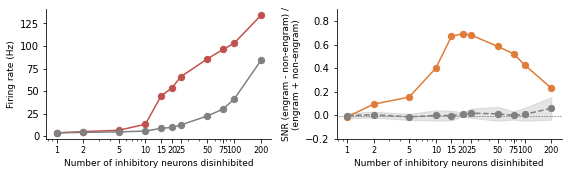

In [6]:
IN_CSV      = "data/fig8_9/ingram_snr_data_ie.csv"
group_sizes = [200, 100, 75, 50, 25, 20, 15, 10, 5, 2, 1]

df  = pd.read_csv(IN_CSV)
top = df[df["kind"] == "top"].set_index("n").reindex(group_sizes)
rest = df[df["kind"] == "rest"]

x = np.array(group_sizes, dtype=float)

top_r_eng = top["rate_engram"].values
top_r_non = top["rate_nonengram"].values
top_snr_s = top["snr_stim"].values
top_snr_b = top["snr_base"].values

rest_snr_s_mean = rest.groupby("n")["snr_stim"].mean().reindex(group_sizes).values
rest_snr_s_std  = rest.groupby("n")["snr_stim"].std().reindex(group_sizes).values

def plot_line_with_band(ax, x, mean, std, color, label, linestyle="--"):
    valid = ~np.isnan(mean)
    ax.plot(x[valid], mean[valid], color=color, lw=1.5,
            linestyle=linestyle, zorder=2, label=label)
    ax.scatter(x[valid], mean[valid], color=color, s=40, zorder=3)
    ax.fill_between(x[valid],
                    mean[valid] - std[valid],
                    mean[valid] + std[valid],
                    color=color, alpha=0.2, zorder=1)

# Plotting
fig, (ax_rate, ax_snr) = plt.subplots(1, 2, figsize=(8, 2.5))

# Activity
valid = ~np.isnan(top_r_eng)
ax_rate.plot(x[valid], top_r_eng[valid], color="#C0504D", lw=1.5,
             zorder=2, label="engram (top)")
ax_rate.scatter(x[valid], top_r_eng[valid], color="#C0504D", s=40, zorder=3)

valid = ~np.isnan(top_r_non)
ax_rate.plot(x[valid], top_r_non[valid], color="grey", lw=1.5,
             zorder=2, label="non-engram (top)")
ax_rate.scatter(x[valid], top_r_non[valid], color="grey", s=40, zorder=3)

ax_rate.set_xscale("log")
ax_rate.set_xticks(x)
ax_rate.set_xticklabels(group_sizes, fontsize=8)
ax_rate.set_ylabel("Firing rate (Hz)", fontsize=9)
ax_rate.set_xlabel("Number of inhibitory neurons disinhibited", fontsize=9)
ax_rate.spines["top"].set_visible(False)
ax_rate.spines["right"].set_visible(False)

# SNR
valid = ~np.isnan(top_snr_s)
ax_snr.plot(x[valid], top_snr_s[valid], color="#E07B39", lw=1.5,
            zorder=2, label="600-601s (top)")
ax_snr.scatter(x[valid], top_snr_s[valid], color="#E07B39", s=40, zorder=3)

plot_line_with_band(ax_snr, x, rest_snr_s_mean, rest_snr_s_std,
                    "grey", "600-601s (rest)")

ax_snr.set_xscale("log")
ax_snr.set_xticks(x)
ax_snr.set_xticklabels(group_sizes, fontsize=8)
ax_snr.set_ylabel("SNR (engram - non-engram) /\n(engram + non-engram)", fontsize=9)
ax_snr.set_xlabel("Number of inhibitory neurons disinhibited", fontsize=9)
ax_snr.axhline(-0.006, color="black", lw=0.6, ls=":", zorder=1)
ax_snr.spines["top"].set_visible(False)
ax_snr.spines["right"].set_visible(False)
ax_snr.set_ylim(-0.2, 0.9)

plt.tight_layout()
plt.show()

## Fig 9: Random connectivity foreshadows which inhibitory neurons become the ingram.

N_I=2000, total_exc=8000


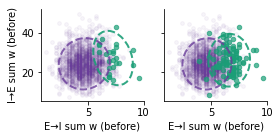

In [7]:
BEFORE_PATH = "data/fig8_9/full_before_engram_weights_and_connectivity_iall_300sec.npz"
GROUPS_PATH = "data/fig8_9/42_inhibitory_groups_topN.npz"

E_MIN, E_MAX = 0, 784
RANDOM_SEED  = 0
N_PERM       = 200

PLOT_SIZES   = [25, 100]

COLOR_ENGRAM = "#1b9e77"
COLOR_OTHER  = "#6a3d9a"

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

def add_cov_ellipse(ax, x, y, n_std=2.0, edgecolor="k", linestyle="-", alpha=0.9, linewidth=2.0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3:
        return
    cov  = np.cov(x, y)
    mean = np.array([x.mean(), y.mean()])
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals  = vals[order]; vecs = vecs[:, order]
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  fill=False, edgecolor=edgecolor, linestyle=linestyle,
                  linewidth=linewidth, alpha=alpha, zorder=5)
    ax.add_patch(ell)

def load_ingram_groups(npz_path):
    d = np.load(npz_path, allow_pickle=False)
    groups = {}
    for key in d.files:
        if key.startswith("top_"):
            n = int(key.split("_")[1])
            groups[n] = d[key].astype(int)
    return groups

def compute_before_features(before_path):
    d = np.load(before_path)
    total_exc  = int(d["total_exc"])
    total_inh  = int(d["total_inh"])
    N_I        = total_inh

    pre_EI, post_EI, w_EI = d["pre_EI"], d["post_EI"], d["w_EI"] * 1e9
    pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]

    m_EI = (pre_EI >= E_MIN) & (pre_EI <= E_MAX)
    EI_sum_in = np.bincount(post_EI[m_EI] - total_exc,
                            weights=w_EI[m_EI], minlength=N_I).astype(float)

    m_IE = (post_IE >= E_MIN) & (post_IE <= E_MAX)
    IE_sum_out = np.bincount(pre_IE[m_IE] - total_exc,
                             weights=w_IE[m_IE], minlength=N_I).astype(float)

    return N_I, total_exc, EI_sum_in, IE_sum_out

groups = load_ingram_groups(GROUPS_PATH)
N_I, total_exc, EI_in, IE_out = compute_before_features(BEFORE_PATH)
print(f"N_I={N_I}, total_exc={total_exc}")

%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

for ax, n in zip(axes, PLOT_SIZES):
    if n not in groups:
        ax.set_title(f"top-{n} not found", fontsize=8)
        continue

    abs_ids = groups[n]
    rel_ids = abs_ids - total_exc
    rel_ids = rel_ids[(rel_ids >= 0) & (rel_ids < N_I)]

    is_engram = np.zeros(N_I, dtype=bool)
    is_engram[rel_ids] = True

    X = np.column_stack([EI_in, IE_out])
    y = is_engram.astype(int)

    xv = np.asarray(EI_in,  float)
    yv = np.asarray(IE_out, float)
    valid = np.isfinite(xv) & np.isfinite(yv)
    m_pos = valid &  is_engram
    m_neg = valid & ~is_engram

    ax.scatter(xv[m_neg], yv[m_neg], s=14, alpha=0.05, color=COLOR_OTHER,
               label="non-ingram", rasterized=True, zorder=2)
    ax.scatter(xv[m_pos], yv[m_pos], s=20, alpha=0.70, color=COLOR_ENGRAM,
               label=f"ingram (top {n})", rasterized=True, zorder=3)

    add_cov_ellipse(ax, xv[m_neg], yv[m_neg], n_std=2.0,
                    edgecolor=COLOR_OTHER,  linestyle="--", alpha=0.8, linewidth=2.0)
    add_cov_ellipse(ax, xv[m_pos], yv[m_pos], n_std=2.0,
                    edgecolor=COLOR_ENGRAM, linestyle="--", alpha=0.9, linewidth=2.0)

    ax.set_xlabel("E→I sum w (before)")
    style_axes(ax)

axes[0].set_ylabel("I→E sum w (before)")

plt.tight_layout()
plt.show()

N_I=2000, total_exc=8000


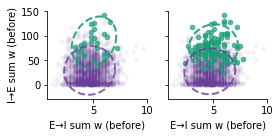

In [8]:
BEFORE_PATH = "data/fig8_9/ie_full_before_engram_weights_and_connectivity_iall_300sec.npz"
GROUPS_PATH = "data/fig8_9/42_inhibitory_groups_topN_ie.npz"

E_MIN, E_MAX = 0, 784
RANDOM_SEED  = 0
N_PERM       = 200

PLOT_SIZES   = [25, 100]

COLOR_ENGRAM = "#1b9e77"
COLOR_OTHER  = "#6a3d9a"

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

def add_cov_ellipse(ax, x, y, n_std=2.0, edgecolor="k", linestyle="-", alpha=0.9, linewidth=2.0):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3:
        return
    cov  = np.cov(x, y)
    mean = np.array([x.mean(), y.mean()])
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals  = vals[order]; vecs = vecs[:, order]
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  fill=False, edgecolor=edgecolor, linestyle=linestyle,
                  linewidth=linewidth, alpha=alpha, zorder=5)
    ax.add_patch(ell)

def load_ingram_groups(npz_path):
    d = np.load(npz_path, allow_pickle=False)
    groups = {}
    for key in d.files:
        if key.startswith("top_"):
            n = int(key.split("_")[1])
            groups[n] = d[key].astype(int)
    return groups

def compute_before_features(before_path):
    d = np.load(before_path)
    total_exc  = int(d["total_exc"])
    total_inh  = int(d["total_inh"])
    N_I        = total_inh

    pre_EI, post_EI, w_EI = d["pre_EI"], d["post_EI"], d["w_EI"] * 1e9
    pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]

    m_EI = (pre_EI >= E_MIN) & (pre_EI <= E_MAX)
    EI_sum_in = np.bincount(post_EI[m_EI] - total_exc,
                            weights=w_EI[m_EI], minlength=N_I).astype(float)

    m_IE = (post_IE >= E_MIN) & (post_IE <= E_MAX)
    IE_sum_out = np.bincount(pre_IE[m_IE] - total_exc,
                             weights=w_IE[m_IE], minlength=N_I).astype(float)

    return N_I, total_exc, EI_sum_in, IE_sum_out

groups = load_ingram_groups(GROUPS_PATH)
N_I, total_exc, EI_in, IE_out = compute_before_features(BEFORE_PATH)
print(f"N_I={N_I}, total_exc={total_exc}")

%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

for ax, n in zip(axes, PLOT_SIZES):
    if n not in groups:
        ax.set_title(f"top-{n} not found", fontsize=8)
        continue

    abs_ids = groups[n]
    rel_ids = abs_ids - total_exc
    rel_ids = rel_ids[(rel_ids >= 0) & (rel_ids < N_I)]

    is_engram = np.zeros(N_I, dtype=bool)
    is_engram[rel_ids] = True

    X = np.column_stack([EI_in, IE_out])
    y = is_engram.astype(int)

    xv = np.asarray(EI_in,  float)
    yv = np.asarray(IE_out, float)
    valid = np.isfinite(xv) & np.isfinite(yv)
    m_pos = valid &  is_engram
    m_neg = valid & ~is_engram

    ax.scatter(xv[m_neg], yv[m_neg], s=14, alpha=0.05, color=COLOR_OTHER,
               label="non-ingram", rasterized=True, zorder=2)
    ax.scatter(xv[m_pos], yv[m_pos], s=20, alpha=0.70, color=COLOR_ENGRAM,
               label=f"ingram (top {n})", rasterized=True, zorder=3)

    add_cov_ellipse(ax, xv[m_neg], yv[m_neg], n_std=2.0,
                    edgecolor=COLOR_OTHER,  linestyle="--", alpha=0.8, linewidth=2.0)
    add_cov_ellipse(ax, xv[m_pos], yv[m_pos], n_std=2.0,
                    edgecolor=COLOR_ENGRAM, linestyle="--", alpha=0.9, linewidth=2.0)

    ax.set_xlabel("E→I sum w (before)")
    style_axes(ax)

axes[0].set_ylabel("I→E sum w (before)")

plt.tight_layout()
plt.show()


===== Predictors: EI + IE =====


  top-25 iall        | AUC=0.971±0.010 | pos=25 neg=1975 folds=5
  top-100 iall       | AUC=0.918±0.021 | pos=100 neg=1900 folds=5
  top-25 ie          | AUC=0.948±0.030 | pos=25 neg=1975 folds=5
  top-100 ie         | AUC=0.925±0.020 | pos=100 neg=1900 folds=5

===== Predictors: IE only =====
  top-25 iall        | AUC=0.626±0.120 | pos=25 neg=1975 folds=5
  top-100 iall       | AUC=0.584±0.063 | pos=100 neg=1900 folds=5
  top-25 ie          | AUC=0.948±0.029 | pos=25 neg=1975 folds=5
  top-100 ie         | AUC=0.924±0.022 | pos=100 neg=1900 folds=5

===== Predictors: EI only =====
  top-25 iall        | AUC=0.966±0.017 | pos=25 neg=1975 folds=5
  top-100 iall       | AUC=0.916±0.021 | pos=100 neg=1900 folds=5
  top-25 ie          | AUC=0.602±0.038 | pos=25 neg=1975 folds=5
  top-100 ie         | AUC=0.585±0.050 | pos=100 neg=1900 folds=5


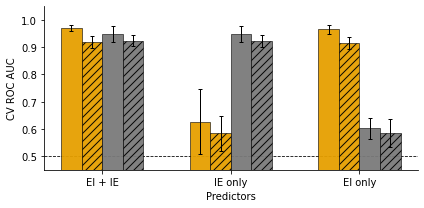

In [9]:
E_MIN, E_MAX = 0, 784
RANDOM_SEED  = 0

NETWORKS = {
    "iall": {
        "before_path": "data/fig8_9/full_before_engram_weights_and_connectivity_iall_300sec.npz",
        "groups_path": "data/fig8_9/42_inhibitory_groups_topN.npz",
    },
    "ie": {
        "before_path": "data/fig8_9/ie_full_before_engram_weights_and_connectivity_iall_300sec.npz",
        "groups_path": "data/fig8_9/42_inhibitory_groups_topN_ie.npz",
    },
}

GROUP_SIZES = [25, 100]

PREDICTOR_SETS = {
    "EI + IE": ["EI_sum_in_0_784", "IE_sum_out_0_784"],
    "IE only": ["IE_sum_out_0_784"],
    "EI only": ["EI_sum_in_0_784"],
}

COLOR_IALL = "#E69F00"
COLOR_IE   = "#7A7A7A"
HATCH_100  = "///"

def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

def load_ingram_group(groups_path, n):
    """Load absolute I neuron indices for top-n group."""
    d = np.load(groups_path, allow_pickle=False)
    key = f"top_{n}"
    if key not in d.files:
        raise KeyError(f"Key '{key}' not found in {groups_path}. Available: {d.files}")
    return d[key].astype(int)

def compute_before_features(before_path):
    d = np.load(before_path)
    total_exc  = int(d["total_exc"])
    total_inh  = int(d["total_inh"])
    inh_offset = total_exc
    N_I        = total_inh

    pre_EI, post_EI, w_EI = d["pre_EI"], d["post_EI"], d["w_EI"] * 1e9
    pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]

    m_EI = (pre_EI >= E_MIN) & (pre_EI <= E_MAX)
    EI_sum_in = np.bincount(post_EI[m_EI] - inh_offset,
                            weights=w_EI[m_EI], minlength=N_I)

    m_IE = (post_IE >= E_MIN) & (post_IE <= E_MAX)
    IE_sum_out = np.bincount(pre_IE[m_IE] - inh_offset,
                             weights=w_IE[m_IE], minlength=N_I)

    feature_dict = {
        "EI_sum_in_0_784":  EI_sum_in,
        "IE_sum_out_0_784": IE_sum_out,
    }
    return N_I, total_exc, feature_dict

def evaluate_auc(before_path, abs_positive_ids, total_exc, feature_dict, N_I, predictor_names):
    # convert absolute to relative indices
    rel_positive_ids = abs_positive_ids - total_exc
    rel_positive_ids = np.unique(rel_positive_ids[(rel_positive_ids >= 0) & (rel_positive_ids < N_I)])

    if rel_positive_ids.size == 0:
        raise ValueError("No valid positive IDs after converting to relative indices.")

    X = np.column_stack([feature_dict[name] for name in predictor_names])
    y = np.zeros(N_I, dtype=int)
    y[rel_positive_ids] = 1

    n_pos    = int(y.sum())
    n_neg    = int((1 - y).sum())
    n_splits = min(5, n_pos, n_neg)
    if n_splits < 2:
        raise ValueError(f"n_splits < 2 (n_pos={n_pos}, n_neg={n_neg})")

    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED)
    )
    cv   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    return {
        "mean_auc": float(aucs.mean()),
        "std_auc":  float(aucs.std()),
        "n_pos":    n_pos,
        "n_neg":    n_neg,
        "n_splits": n_splits,
    }


# 4 conditions: top-20 iall, top-100 iall, top-20 ie, top-100 ie
conditions = [
    (f"top-{n} {net}", net, n)
    for net in ["iall", "ie"]
    for n in GROUP_SIZES
]

results = {}

for predictor_label, predictor_names in PREDICTOR_SETS.items():
    results[predictor_label] = {}
    print(f"\n===== Predictors: {predictor_label} =====")

    for condition_label, network_key, group_size in conditions:
        cfg = NETWORKS[network_key]

        N_I, total_exc, feature_dict = compute_before_features(cfg["before_path"])
        abs_ids = load_ingram_group(cfg["groups_path"], group_size)

        out = evaluate_auc(cfg["before_path"], abs_ids, total_exc,
                           feature_dict, N_I, predictor_names)
        results[predictor_label][condition_label] = out

        print(f"  {condition_label:18s} | AUC={out['mean_auc']:.3f}±{out['std_auc']:.3f} | "
              f"pos={out['n_pos']} neg={out['n_neg']} folds={out['n_splits']}")

predictor_labels = list(PREDICTOR_SETS.keys())
x      = np.arange(len(predictor_labels))
width  = 0.16
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

plot_specs = [
    ("top-25 iall",  COLOR_IALL, None),
    ("top-100 iall", COLOR_IALL, HATCH_100),
    ("top-25 ie",    COLOR_IE,   None),
    ("top-100 ie",   COLOR_IE,   HATCH_100),
]

fig, ax = plt.subplots(figsize=(6, 3))

for i, (condition_label, color, hatch) in enumerate(plot_specs):
    means = [results[p][condition_label]["mean_auc"] for p in predictor_labels]
    stds  = [results[p][condition_label]["std_auc"]  for p in predictor_labels]

    ax.bar(
        x + offsets[i], means, width=width, yerr=stds,
        color=color, hatch=hatch, edgecolor="black", linewidth=0.6,
        alpha=0.95, error_kw=dict(elinewidth=1, capsize=2, capthick=1),
        label=condition_label,
    )

ax.axhline(0.5, color="black", lw=0.8, ls="--", zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(predictor_labels)
ax.set_ylabel("CV ROC AUC")
ax.set_xlabel("Predictors")
ax.set_ylim(0.45, 1.05)
style_axes(ax)
plt.tight_layout()
plt.show()

## Fig. S5: Ingram detection in the I-to-E plasticity network.

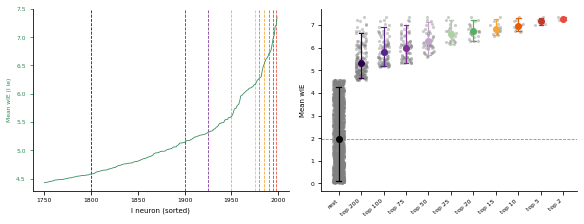

In [10]:
GROUPS_FILE  = "data/fig8_9/42_inhibitory_groups_topN_ie.npz"
WEIGHTS_FILE = "data/fig8_9/ie_full_after_engram_weights_and_connectivity_iall_600sec.npz"

d_ie = np.load(WEIGHTS_FILE)
grp  = np.load(GROUPS_FILE, allow_pickle=True)

group_sizes = [200, 100, 75, 50, 25, 20, 15, 10, 5, 2, 1]
palette     = ["#000000",
               "#2D004B", "#542789", "#7B3294", "#C2A5CF",
               "#ACD39E", "#5AAE61", "#F7A535", "#E85D04",
               "#C0392B", "#E74C3C"]
x_pos   = np.arange(len(group_sizes) + 1)
xlabels = ["rest"] + [f"top {n}" for n in group_sizes]

def has_data(subsets):
    return any(np.any(np.isfinite(s)) for s in subsets)

def draw_boxplot(ax, subsets, ylabel):
    any_drawn = False

    indexed = [(i, s, palette[i]) for i, s in enumerate(subsets)
               if i < len(palette) and np.any(np.isfinite(s))]

    for i, subset, col in indexed:
        s = subset[np.isfinite(subset)]
        if len(s) == 0:
            continue
        any_drawn = True
        x = x_pos[i]

        jitter = np.random.uniform(-0.25, 0.25, size=len(s))
        ax.scatter(x + jitter, s, color="grey", rasterized=True, s=10, alpha=0.4,
                   linewidths=0, zorder=1)

        m    = np.mean(s)
        w_lo = np.percentile(s, 5)
        w_hi = np.percentile(s, 95)

        if w_hi > w_lo:
            ax.plot([x, x], [w_lo, w_hi], color=col, lw=1.2, zorder=3)
            ax.plot([x-0.10, x+0.10], [w_lo, w_lo], color=col, lw=1.2, zorder=3)
            ax.plot([x-0.10, x+0.10], [w_hi, w_hi], color=col, lw=1.2, zorder=3)
        ax.scatter(x, m, color=col, s=50, zorder=4, linewidths=0)

    shown_ticks  = [x_pos[i] for i, _, _ in indexed]
    shown_labels = [xlabels[i] for i, _, _ in indexed]
    ax.set_xticks(shown_ticks)
    ax.set_xticklabels(shown_labels, fontsize=6, rotation=40, ha="right")
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return any_drawn

def compute_sorted_wIE(d):
    total_exc = int(d["total_exc"])
    if "total_inh" in d.files:
        total_inh = int(d["total_inh"])
    else:
        max_id = int(np.max([np.max(d["pre_IE"]), np.max(d["post_IE"])]))
        total_inh = (max_id + 1) - total_exc

    pre_IE, post_IE, w_IE = d["pre_IE"], d["post_IE"], d["w_IE"]
    E_engram = np.arange(0, 784)

    mask_ie = np.isin(post_IE, E_engram) & np.isfinite(w_IE)
    n_ie = np.zeros(total_inh, dtype=int)
    s_ie = np.zeros(total_inh, dtype=float)
    for i_abs, w in zip(pre_IE[mask_ie], w_IE[mask_ie]):
        idx = i_abs - total_exc
        n_ie[idx] += 1
        s_ie[idx] += w

    avg_wIE = np.full(total_inh, np.nan)
    has_ie  = n_ie > 0
    avg_wIE[has_ie] = s_ie[has_ie] / n_ie[has_ie]

    has_ie_mask = np.isfinite(avg_wIE)
    sort_order  = np.argsort(avg_wIE[has_ie_mask])
    sorted_wIE  = avg_wIE[has_ie_mask][sort_order]
    neuron_ids  = np.where(has_ie_mask)[0] + total_exc
    sorted_ids  = neuron_ids[sort_order]

    return sorted_wIE, sorted_ids, total_exc, total_inh

sorted_wIE, sorted_ids, total_exc, total_inh = compute_sorted_wIE(d_ie)
N = len(sorted_wIE)

groups_ids = [grp["rest"]] + [grp[f"top_{n}"] for n in group_sizes]

# IE subsets
id_to_rank = {nid: i for i, nid in enumerate(sorted_ids)}
subsets_ie = []
for ids in groups_ids:
    ranks = np.array([id_to_rank[nid] for nid in ids if nid in id_to_rank])
    subsets_ie.append(sorted_wIE[ranks] if len(ranks) > 0 else np.array([np.nan]))

fig, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

lo, hi = N - max(group_sizes) - 50, N
ax_top.plot(np.arange(lo, hi), sorted_wIE[lo:hi], color="seagreen", lw=0.8)
ax_top.set_ylabel("Mean wIE (I ie)", color="seagreen", fontsize=6)
ax_top.tick_params(axis="y", colors="seagreen", labelsize=6)
for n, color in zip(group_sizes, palette[1:]):
    ax_top.axvline(N - n, color=color, lw=0.8, ls="--", zorder=0, label=f"top {n}")
ax_top.set_xlabel("I neuron (sorted)", fontsize=7)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.tick_params(labelsize=6)

draw_boxplot(ax_bot, subsets_ie, "Mean wIE")

grey_ie = subsets_ie[0][np.isfinite(subsets_ie[0])]
if len(grey_ie) > 0:
    ax_bot.axhline(np.nanmean(grey_ie), color="#888888", lw=0.8, ls="--", zorder=0)

plt.show()

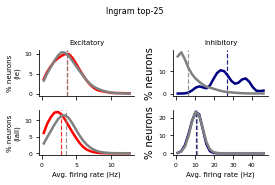

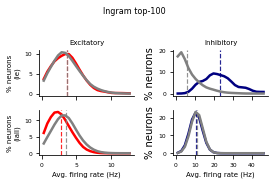

In [11]:
base_dir_iall = "data/fig8_9/detected_ingram_iall_42_3.0_10.0_42_615sec"
base_dir_ie   = "data/fig8_9/detected_ingram_ie_42_3.0_10.0_42_615sec"

GROUPS_PATH_IALL = "data/fig8_9/42_inhibitory_groups_topN.npz"
GROUPS_PATH_IE   = "data/fig8_9/42_inhibitory_groups_topN_ie.npz"

PLOT_SIZES = [25, 100]

tmin, tmax = 599, 600
win_sec = tmax - tmin

E_LOW_MIN,  E_LOW_MAX  = 0,    784
E_HIGH_MIN, E_HIGH_MAX = 784,  8000
I_MIN, I_MAX           = 8000, 10000
N_I                    = 2000

N_BOOT           = 0
SMOOTH_SIGMA_BINS = 1.25
N_BINS           = 25

COL_E = ["red",  "grey"]
COL_I = ["navy", "grey"]

def load_ingram_group(groups_path, n):
    d = np.load(groups_path, allow_pickle=False)
    key = f"top_{n}"
    if key not in d.files:
        raise KeyError(f"'{key}' not in {groups_path}. Available: {d.files}")
    return d[key].astype(int)  # absolute neuron indices

def compute_group_rates(base_dir, ingram_abs_ids):
    spike_path = os.path.join(base_dir, "spikes.txt")
    data   = np.loadtxt(spike_path)
    neuron = data[:, 0].astype(int)
    time   = data[:, 1]

    mask_w   = (time >= tmin) & (time <= tmax)
    neuron_w = neuron[mask_w]

    # ingram: absolute ids clipped to valid I range
    ingram_ids = ingram_abs_ids[(ingram_abs_ids >= I_MIN) & (ingram_abs_ids < I_MAX)]
    all_inh_ids = np.arange(I_MIN, I_MAX, dtype=int)
    rest_ids    = np.setdiff1d(all_inh_ids, ingram_ids, assume_unique=False)

    E_low_ids  = np.arange(E_LOW_MIN,  E_LOW_MAX,  dtype=int)
    E_high_ids = np.arange(E_HIGH_MIN, E_HIGH_MAX, dtype=int)

    def rates_for_ids(ids):
        if ids.size == 0:
            return np.array([], dtype=float)
        id_min = int(ids.min())
        id_max = int(ids.max())
        mask   = np.isin(neuron_w, ids)
        counts = np.bincount(neuron_w[mask] - id_min,
                             minlength=(id_max - id_min + 1))
        if np.array_equal(ids, np.arange(id_min, id_max + 1)):
            return counts / win_sec
        return counts[ids - id_min] / win_sec

    return {
        "E_low":    rates_for_ids(E_low_ids),
        "E_high":   rates_for_ids(E_high_ids),
        "I_ingram": rates_for_ids(ingram_ids),
        "I_rest":   rates_for_ids(rest_ids),
    }

def gaussian_kernel1d(sigma_bins, radius=None):
    if sigma_bins <= 0:
        return np.array([1.0])
    if radius is None:
        radius = int(np.ceil(4 * sigma_bins))
    x = np.arange(-radius, radius + 1)
    k = np.exp(-(x**2) / (2 * sigma_bins**2))
    return k / k.sum()

def percent_hist_smoothed(x, bins, sigma_bins=1.25):
    x = np.asarray(x)
    if x.size == 0:
        return 0.5 * (bins[:-1] + bins[1:]), np.zeros(len(bins) - 1)
    counts, _ = np.histogram(x, bins=bins)
    pct = counts / x.size * 100.0
    k   = gaussian_kernel1d(sigma_bins)
    pct_s = np.convolve(pct, k, mode="same")
    s = pct_s.sum()
    if s > 0:
        pct_s *= 100.0 / s
    return 0.5 * (bins[:-1] + bins[1:]), pct_s

def plot_panel(ax, r1, r2, bins, colors, labels, rng,
               n_boot=0, sigma_bins=1.25):
    c1, c2 = colors
    for _ in range(n_boot):
        for r, c in [(r1, c1), (r2, c2)]:
            if r.size > 0:
                s = r[rng.integers(0, r.size, size=r.size)]
                x, y = percent_hist_smoothed(s, bins=bins, sigma_bins=sigma_bins)
                ax.plot(x, y, color=c, alpha=0.18, lw=1.0)
    for r, c, lbl in [(r1, c1, labels[0]), (r2, c2, labels[1])]:
        if r.size > 0:
            x, y = percent_hist_smoothed(r, bins=bins, sigma_bins=sigma_bins)
            ax.plot(x, y, color=c, lw=2.5, label=f"{lbl} (n={r.size})")
            ax.axvline(r.mean(), color=c, ls="--", lw=1.2, alpha=0.85)
    ax.set_ylabel("% neurons")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

%matplotlib inline
rng = np.random.default_rng(0)

for n in PLOT_SIZES:
    ingram_iall = load_ingram_group(GROUPS_PATH_IALL, n)
    ingram_ie   = load_ingram_group(GROUPS_PATH_IE,   n)

    rates_iall = compute_group_rates(base_dir_iall, ingram_iall)
    rates_ie   = compute_group_rates(base_dir_ie,   ingram_ie)

    exc_all  = np.concatenate([rates_iall["E_low"],    rates_iall["E_high"],
                                rates_ie["E_low"],     rates_ie["E_high"]])
    inh_all  = np.concatenate([rates_iall["I_ingram"], rates_iall["I_rest"],
                                rates_ie["I_ingram"],  rates_ie["I_rest"]])
    exc_bins = np.linspace(0, max(float(exc_all.max()) if exc_all.size else 1e-9, 1e-9), N_BINS + 1)
    inh_bins = np.linspace(0, max(float(inh_all.max()) if inh_all.size else 1e-9, 1e-9), N_BINS + 1)

    fig, axes = plt.subplots(2, 2, figsize=(4, 2.5), sharex="col", sharey=False)
    fig.suptitle(f"Ingram top-{n}", fontsize=8, y=1.01)

    # row 0 = ie, row 1 = iall
    for row, (rates, net_label) in enumerate([(rates_ie, "ie"), (rates_iall, "iall")]):
        plot_panel(axes[row, 0], rates["E_low"], rates["E_high"],
                   bins=exc_bins, colors=COL_E,
                   labels=("E 0-784", "E 784-8000"),
                   rng=rng, n_boot=N_BOOT, sigma_bins=SMOOTH_SIGMA_BINS)
        axes[row, 0].set_ylabel(f"% neurons\n({net_label})", fontsize=7)

        plot_panel(axes[row, 1], rates["I_ingram"], rates["I_rest"],
                   bins=inh_bins, colors=COL_I,
                   labels=(f"I ingram (top {n})", "I rest"),
                   rng=rng, n_boot=N_BOOT, sigma_bins=SMOOTH_SIGMA_BINS)

    axes[0, 0].set_title("Excitatory", fontsize=7)
    axes[0, 1].set_title("Inhibitory", fontsize=7)
    axes[1, 0].set_xlabel("Avg. firing rate (Hz)", fontsize=7)
    axes[1, 1].set_xlabel("Avg. firing rate (Hz)", fontsize=7)

    for ax in axes.flat:
        ax.tick_params(labelsize=6)
        # ax.legend(fontsize=5, frameon=False)

    plt.tight_layout()
    plt.show()